# Runs all QM8 experiments with the full dataset!

## N.B this version: all tests were run for 20 repeats except Weave and Sm2Img (As htye were very very slow)

(Remember that the atomization energy is the energy required to form 1 mol of gaseous atoms from 1 mol of the molecule in its standard state under standard conditions)

QM& Regression, 7000ish compounds, Stratified split, MAE

Best conventionall KRR 10.22, best graph: ANI-1 2.86

This is a neater version of qm7_gnt_2

Use tdaf-tf2p7h2             C:\Users\ella_\.conda\envs\tdaf-tf2p7h2

In [10]:
import sys
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

import deepchem as dc
#from deepchem.feat import SmilesToImage

import tensorflow as tf
import os
import sys
import rdkit
import h5py
import helper_functions as h
import pandas

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.tri
import rdkit.Chem as Chem
import rdkit.Chem.AllChem as AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
import mpl_toolkits.mplot3d
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from collections import Counter

print("TensorFlow version: " + tf.__version__)

# topology stuff
from gtda.plotting import plot_point_cloud
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_diagram
from gtda.diagrams import PersistenceEntropy
from gtda.diagrams import NumberOfPoints
from gtda.diagrams import Amplitude
from sklearn.pipeline import make_union, Pipeline

# fixc this at some point
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

#import projection
#from projection.molecule import Molecule
#from projection.pdbmolecule import PDBMolecule
#from projection.mol2molecule import Mol2Molecule

import helper_functions as h
loaders, classification_datasets, regression_datasets, metric_types = h.deepchem_dataset_dictionaries()

# change THIS

dataset_name='qm8'

data_dir=r'F:\Nextcloud\science\Datasets\topol_datasets'
results_dir=r"F:\Nextcloud\science\results\topology_and_graphs\d_" + dataset_name

data_dir=r'C:\Users\eg16993\OneDrive - University of Bristol\Documents\Datasets\topol_datasets'

results_dir=r"C:\Users\eg16993\OneDrive - University of Bristol\Documents\Results\graphs_and_topology\d_" + dataset_name


test_file=dataset_name + '.csv'
data_file_name=dataset_name + '_topological_features.hdf5'
loader = loaders[dataset_name]
make_dataset=False # whether to recalc the dataset

print(f"DeepChem version: {dc.__version__}")

############################### settings for all experiments #################

best_con = 123.7 #multitask value   #10.22
best_graph = 8.8 # for dtnn, didn't run ani#2.86

num_repeats= 5
num_epochs = 500

metric_labels=['mean_squared_error','pearson_r2_score',
               'mae_score', 'rmse']


metric1 = dc.metrics.Metric(dc.metrics.mean_squared_error)
metric2 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
metric3 = dc.metrics.Metric(dc.metrics.mae_score)
metrics = [metric1, metric2, metric3]
selected_metric = 2 #which metric to use for callback

Splitter = dc.splits.SingletaskStratifiedSplitter()

split_fraction=[0.01, 0.1, 0.1]


TensorFlow version: 2.7.0
DeepChem version: 2.5.0


In [11]:
hdf5_file_name='qm8_topological_features.hdf5'
fh = h5py.File(os.path.join(data_dir,hdf5_file_name), 'r+')
num_of_rows, num_of_molecules = h.basic_info_hdf5_dataset(fh, label='molID')

num_of_ rows is:	21747
num_of_molecules is:	 128
MolID: count
Counter({127: 21620, 0: 1, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1, 9: 1, 10: 1, 11: 1, 12: 1, 13: 1, 14: 1, 15: 1, 16: 1, 17: 1, 18: 1, 19: 1, 20: 1, 21: 1, 22: 1, 23: 1, 24: 1, 25: 1, 26: 1, 27: 1, 28: 1, 29: 1, 30: 1, 31: 1, 32: 1, 33: 1, 34: 1, 35: 1, 36: 1, 37: 1, 38: 1, 39: 1, 40: 1, 41: 1, 42: 1, 43: 1, 44: 1, 45: 1, 46: 1, 47: 1, 48: 1, 49: 1, 50: 1, 51: 1, 52: 1, 53: 1, 54: 1, 55: 1, 56: 1, 57: 1, 58: 1, 59: 1, 60: 1, 61: 1, 62: 1, 63: 1, 64: 1, 65: 1, 66: 1, 67: 1, 68: 1, 69: 1, 70: 1, 71: 1, 72: 1, 73: 1, 74: 1, 75: 1, 76: 1, 77: 1, 78: 1, 79: 1, 80: 1, 81: 1, 82: 1, 83: 1, 84: 1, 85: 1, 86: 1, 87: 1, 88: 1, 89: 1, 90: 1, 91: 1, 92: 1, 93: 1, 94: 1, 95: 1, 96: 1, 97: 1, 98: 1, 99: 1, 100: 1, 101: 1, 102: 1, 103: 1, 104: 1, 105: 1, 106: 1, 107: 1, 108: 1, 109: 1, 110: 1, 111: 1, 112: 1, 113: 1, 114: 1, 115: 1, 116: 1, 117: 1, 118: 1, 119: 1, 120: 1, 121: 1, 122: 1, 123: 1, 124: 1, 125: 1, 126: 1})


In [12]:
fh.keys()

<KeysViewHDF5 ['E1-CAM', 'E1-CC2', 'E1-PBE0', 'E1-PBE0_2', 'E2-CAM', 'E2-CC2', 'E2-PBE0', 'E2-PBE0_2', 'PCA_1', 'PCA_10', 'PCA_11', 'PCA_12', 'PCA_13', 'PCA_14', 'PCA_15', 'PCA_16', 'PCA_17', 'PCA_18', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'PCA_6', 'PCA_7', 'PCA_8', 'PCA_9', 'SMILES', 'bottle_1', 'bottle_2', 'bottle_3', 'f1-CAM', 'f1-CC2', 'f1-PBE0', 'f1-PBE0_2', 'f2-CAM', 'f2-CC2', 'f2-PBE0', 'f2-PBE0_2', 'landsc_1', 'landsc_2', 'landsc_3', 'molID', 'no_p_1', 'no_p_2', 'no_p_3', 'pers_S_1', 'pers_S_2', 'pers_S_3', 'pers_img_1', 'pers_img_2', 'pers_img_3', 'wasser_1', 'wasser_2', 'wasser_3']>

In [13]:



#fh['u0_atom'][:]

In [14]:
feature_name_list = ['pers_S_1', 'pers_S_2', 'pers_S_3',
                    'no_p_1', 'no_p_2', 'no_p_3',
                    'bottle_1', 'bottle_2', 'bottle_3',
                    'wasser_1', 'wasser_2', 'wasser_3',
                    'landsc_1', 'landsc_2', 'landsc_3',
                    'pers_img_1', 'pers_img_2', 'pers_img_3']

PCA_list = ['PCA_1', 'PCA_2', 'PCA_3',
           'PCA_4', 'PCA_5', 'PCA_6',
           'PCA_7', 'PCA_8', 'PCA_9',
           'PCA_10', 'PCA_11', 'PCA_12',
           'PCA_13', 'PCA_14', 'PCA_15',
           'PCA_16', 'PCA_17', 'PCA_18']

task_list=["E1-CC2", "E2-CC2", "f1-CC2","f2-CC2",
           "E1-PBE0", "E2-PBE0", "f1-PBE0", "f2-PBE0", 
           "E1-PBE0_2","E2-PBE0_2","f1-PBE0_2","f2-PBE0_2"
           ,"E1-CAM", "E2-CAM", "f1-CAM",  "f2-CAM"]

## Functions

In [15]:
metric_labels

['mean_squared_error', 'pearson_r2_score', 'mae_score', 'rmse']

# Load data


## Create topological datasets

We use Numpy datasets to create the two toplogical datasets and two transformers (used as the controls use them and they are supposed to improve training). The topological dataset is normalised in X and y, PCA is only normalised in y as PCA is a normalisation.

This sorts out the datasets, transformers and splitters for the task

In [16]:
fh['SMILES']

<HDF5 dataset "SMILES": shape (21747,), type "|O">

In [17]:
## loading data from the hdf5 file
X_data = h.load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=feature_name_list)

PCA_X_data = h.load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=PCA_list)

y_data = h.load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=task_list)

SMILES_list = np.array(fh['SMILES'])

# making the datasets
topol_dataset = dc.data.DiskDataset.from_numpy(
    X_data, 
    y_data, 
    ids=SMILES_list)

pca_dataset = dc.data.DiskDataset.from_numpy(
    PCA_X_data, 
    y_data, 
    ids=SMILES_list)

# setting up the splitters for the task
Splitter_Object_tf = dc.splits.SingletaskStratifiedSplitter()
Splitter_Object_pca = dc.splits.SingletaskStratifiedSplitter()

# doing a transform on the data to make it easier for hte NN
# both y and x
transformers_tf = [
    dc.trans.NormalizationTransformer(
        transform_X=True, 
        dataset=topol_dataset),
    dc.trans.NormalizationTransformer(
        transform_y=True, 
        dataset=topol_dataset)]
# only y
transformers_pca = [
    dc.trans.NormalizationTransformer(
        transform_y=True, 
        dataset=pca_dataset)]



Text(0, 0.5, 'No.')

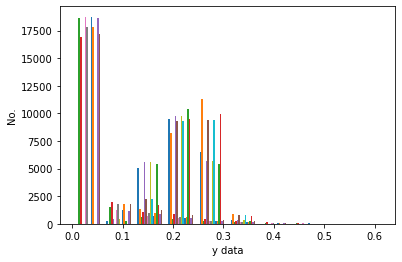

In [18]:
plt.hist(y_data)
plt.xlabel('y data')
plt.ylabel("No.")

# Training on the topological features

#### Topological features

In [19]:
%%time
output_metrics_tf=h.topol_regression_experiment(
    dataset=topol_dataset,
    transformers=transformers_tf,
    Splitter_Object=Splitter_Object_tf,
    tasks=task_list,
    metrics=metrics,
    metric_selector=selected_metric,
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=split_fraction,
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score', 
                   'mae_score', 
                   'rmse']
    )
output_metrics_tf

Metric selected is mae_score


AssertionError: 
Items are not equal:
 ACTUAL: 0.21000000000000002
 DESIRED: 1.0

#### PCA of topological features

In [ ]:
%%time
output_metrics_pca=h.topol_regression_experiment(
    dataset=pca_dataset,
    transformers=transformers_pca,
    Splitter_Object=Splitter_Object_pca,
    tasks=task_list,
    metrics=metrics,
    metric_selector=selected_metric,
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=split_fraction,
    patience=15,
    metric_labels=['mean_squared_error',
                'pearson_r2_score', 
                'mae_score', 
                'rmse']
    )
output_metrics_pca

#### PCA of topological features with no transform

In [ ]:
%%time
output_metrics_pca_no_transform=h.no_transform_topol_regression_experiment(
    dataset=pca_dataset,
    Splitter_Object=Splitter_Object_pca,
    tasks=task_list,
    metrics=metrics,
    metric_selector=selected_metric,
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=split_fraction,
    patience=15,
    metric_labels=['mean_squared_error',
                'pearson_r2_score', 
                'mae_score', 
                'rmse']
    )
output_metrics_pca_no_transform

## 1-D inputs

#### ECFP

In [ ]:
%%time
output_metrics_ecfp = h.deepchem_regression_experiment(
    metrics,
    metric_selector=selected_metric,
    feat_setting='ECFP',
    model_setting='MTR',
    loader=loaders[dataset_name],
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_function=Splitter,
    split_fraction=split_fraction,
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse'])
output_metrics_ecfp

### Coulomb matrix eigenvalues

In [ ]:
%%time
output_metrics_cm_eig = h.deepchem_regression_experiment(
    metrics,
    metric_selector=selected_metric,
    feat_setting='CM_eig',
    model_setting='MTR',
    loader=loaders[dataset_name],
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_function=Splitter,
    split_fraction=split_fraction,
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse'])

output_metrics_cm_eig

### rdkit features

In [ ]:
%%time
output_metrics_rdkit = h.deepchem_regression_experiment(
    metrics,
    metric_selector=selected_metric,
    feat_setting='rdkit',
    model_setting='MTR',
    loader=loaders[dataset_name],
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_function=Splitter,
    split_fraction=split_fraction,
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse'])

output_metrics_rdkit

## MACCS features

In [ ]:
%%time
output_metrics_maccs = h.deepchem_regression_experiment(
    metrics,
    metric_selector=selected_metric,
    feat_setting='MACCS',
    model_setting='MTR',
    loader=loaders[dataset_name],
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_function=Splitter,
    split_fraction=split_fraction,
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse'])

output_metrics_maccs

### graph for 1D features

In [ ]:


data=[output_metrics_ecfp['tr_mae'],
     output_metrics_ecfp['te_mae'],
     output_metrics_maccs['tr_mae'],
     output_metrics_maccs['te_mae'],
     output_metrics_rdkit['tr_mae'],
     output_metrics_rdkit['te_mae'],
     output_metrics_cm_eig['tr_mae'],
     output_metrics_cm_eig['te_mae'],
     output_metrics_tf['tr_mae'],
     output_metrics_tf['te_mae'],
     output_metrics_pca['tr_mae'],
     output_metrics_pca['te_mae']]
      
means=[np.mean(x) for x in data]
stds=[np.std(x) for x in data]


x_positions = [x+1 for x in range(len(means))]
plt.figure(figsize=(16, 9))
plt.rcParams.update({'font.size': 22})

plt.bar(x_positions, means, 
        color=["#1f77f4","#f62728",
               "#1f77f4","#f62728",
               "#1f77f4","#f62728",
               "#88fff4","#552200",
               "#5f77f4","#f62788",
               "#5f77f4","#f62788"], 
        edgecolor='k',
        linewidth='3',
        yerr=stds, 
        error_kw=dict(lw=5, capsize=15, capthick=3))
for i in range(len(means)):
    x=data[i]; plt.plot(np.ones(len(x))*(i+1),x,'o',color="#444444")

axes=plt.gca()
#axes.set_ylim([0.5,4.5])
#axes.set_xlim([0.45,4.55])
x_tick_list=[1.5,3.5,5.5,7.5,9.5,11.5]
plt.xticks(x_tick_list,['ECFP',"MACCS","rdkit","CM_eig","TDAF","PCA-TDAF"])
plt.plot([0.5,max(x_tick_list)+1],[best_con, best_con],'k',linewidth=4,linestyle='-.')
#plt.plot([0.5,max(x_tick_list)+1],[best_graph, best_graph],'g',linewidth=4,linestyle='-.')

plt.ylabel('MAE kcal/mol')
plt.savefig(os.path.join(dataset_name + "1Donly.png"))

## 2D inputs and graph models

In [ ]:
%%time
output_metrics_Sm2Img=h.deepchem_regression_experiment(
    metrics,
    metric_selector=selected_metric,
    dimension=2,
    feat_setting='Smiles2Img',
    model_setting='ChemCeption',
    loader=loaders[dataset_name],
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_function=Splitter,
    split_fraction=split_fraction,
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse'])

output_metrics_Sm2Img.head(3)

In [ ]:
%%time
output_metrics_gc=h.deepchem_regression_experiment(
    metrics,
    metric_selector=selected_metric,
    dimension=2,
    feat_setting='ConvMol',
    model_setting='GraphConv',
    loader=loaders[dataset_name],
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_function=Splitter,
    split_fraction=split_fraction,
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse'])

output_metrics_gc.head(3)

In [ ]:
%%time
output_metrics_weave=h.deepchem_regression_experiment(
    metrics,
    metric_selector=selected_metric,
    dimension=2,
    feat_setting='Weave',
    model_setting='Weave',
    loader=loaders[dataset_name],
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_function=Splitter,
    split_fraction=split_fraction,
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse'])

output_metrics_weave.head(3)

In [ ]:
%%time
output_metrics_cm=h.deepchem_regression_experiment(
    metrics,
    metric_selector=selected_metric,
    dimension=2,
    feat_setting='CM',
    model_setting='DTNN',
    loader=loaders[dataset_name],
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_function=Splitter,
    split_fraction=split_fraction,
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse'])

output_metrics_cm.head(3)

## Write out data and graphs

In [ ]:
list_of_data_frames=[output_metrics_ecfp,
    output_metrics_maccs,
    output_metrics_rdkit,
    output_metrics_cm_eig,
    #output_metrics_Sm2Img,
    output_metrics_gc,
    #output_metrics_weave,
    output_metrics_cm,
    output_metrics_tf,
    output_metrics_pca]

list_of_data_frames_names=["output_metrics_ecfp",
    "output_metrics_maccs",
    "output_metrics_rdkit",
    "output_metrics_cm_eig",
    "output_metrics_Sm2Img",
    "output_metrics_gc",
    "output_metrics_weave",
    "output_metrics_cm",
    "output_metrics_tf",
    "output_metrics_pca"]



In [ ]:
color_list=["#1f77f4","#f62728", # red blue ecfp
                   "#1f77f4","#f62728", #maccs
                   "#1f77f4","#f62728", # rdkit
                   "#88fff4","#552200", #brown green # cmeig
                   "#61ff33","#ffb433", # green orange #sm2img
                   "#61ff33","#ffb433", # gc
                   "#61ff33","#ffb433",      #weave         
                   "#88fff4","#552200", #brown green    #cm           
                   "#5f77f4","#f62788", # pink blue tdaf
                   "#5f77f4","#f62788"] # pca-tdaf

missing_data = [4,6]

In [ ]:
for i in range(len(list_of_data_frames)):
    list_of_data_frames[i].to_csv(os.path.join(
        results_dir, 
        list_of_data_frames_names[i] + '.csv'))


In [ ]:
#Best=1.92
label1='val_mae'
label2='te_mae'

data=[output_metrics_ecfp[label1],
     output_metrics_ecfp[label2],
     output_metrics_maccs[label1],
     output_metrics_maccs[label2],
     output_metrics_rdkit[label1],
     output_metrics_rdkit[label2],
     output_metrics_cm_eig[label1],
     output_metrics_cm_eig[label2],
    # output_metrics_Sm2Img[label1],
    # output_metrics_Sm2Img['te_mae'],
     output_metrics_gc[label1],
     output_metrics_gc[label2],
   #  output_metrics_weave[label1],
   #  output_metrics_weave[label2],
     output_metrics_cm[label1],
     output_metrics_cm[label2],
     output_metrics_tf[label1],
     output_metrics_tf[label2],
     output_metrics_pca[label1],
     output_metrics_pca[label2]]
      
means=[np.mean(x) for x in data]
stds=[np.std(x) for x in data]


x_positions = [x+1 for x in range(len(means))]
plt.figure(figsize=(16, 9))
plt.rcParams.update({'font.size': 22})

plt.bar(x_positions, means, 
        color=["#1f77f4","#f62728", # red blue ecfp
               "#1f77f4","#f62728", #maccs
               "#1f77f4","#f62728", # rdkit
               "#88fff4","#552200", #brown green # cmeig
               "#61ff33","#ffb433", # green orange #sm2img
               "#61ff33","#ffb433", # gc
               "#61ff33","#ffb433",      #weave         
               "#88fff4","#552200", #brown green    #cm           
               "#5f77f4","#f62788", # pink blue tdaf
               "#5f77f4","#f62788"], # pca-tdaf
        edgecolor='k',
        linewidth='3',
        yerr=stds, 
        error_kw=dict(lw=5, capsize=15, capthick=3))
for i in range(len(means)):
    x=data[i]; plt.plot(np.ones(len(x))*(i+1),x,'o',color="#444444")


#axes.set_ylim([0.5,4.5])
#axes.set_xlim([0.45,4.55])
x_tick_list=[1.5,3.5,5.5,7.5,9.5,11.5,13.5,15.5,17.5,19.5]
label_list=['ECFP',
            "MACCS",
            "rdkit",
            "CM_eig",
            #'Sm2Img', 
            'GC', 
            #'Weave', 
            'CM',
            "TDAF",
            "PCA-TDAF"]
x_tick_list = x_tick_list[:len(label_list)]
plt.xticks(x_tick_list,
           label_list)

plt.plot([0.5,max(x_tick_list)+1],[best_con, best_con],'k',linewidth=4,linestyle='dashed')
plt.plot([0.5,max(x_tick_list)+1],[best_con+15, best_con+15],'grey',linewidth=4,linestyle='dotted')

plt.plot([0.5,max(x_tick_list)+1],[best_con-15, best_con-15],'grey',linewidth=4,linestyle='dotted')

plt.plot([0.5,max(x_tick_list)+1],[best_graph, best_graph],'g',linewidth=4,linestyle='-.')

axes=plt.gca()
plt.ylabel('MAE kcal/mol')
plt.savefig(os.path.join(results_dir, dataset_name + "all_data.png"))

In [ ]:
def method_comparison_plotter(
    list_of_data_frames,
    list_of_columns,
    color_list,
    exclusion_list = [],
    df_exclusion_list= [],
    label_list=[],
    best_con=None,
    best_con_error=None,
    best_gr=None,
    best_gr_error=None,
    x_label='',
    y_label='',
    filename='method_comparison',
    rider='all_data.png'):
    
    """Plotter
    list of data frames: list of results
    list_of_columns: which matrics to use (columsn in df)
    color_list = which colours to use
    exclusion_list: whether to miss out a df - either cos missing or unwanted
    df_exclusion_list: whether to miss out a column ONLY if not missing
    label_list: labels per dataset
    best_con: best 1D method
    best_con_error: std err
    best_gr: best graph method
    best_gr_error=None,
    x_label='',
    y_label='',
    filename='method_comparison',
    rider='all_data.png')"""
    
    #Best=1.92
    # pick subset of colours
    if color_list == None:
        color_list=["#1f77f4","#f62728", # red blue ecfp
                   "#1f77f4","#f62728", #maccs
                   "#1f77f4","#f62728", # rdkit
                   "#88fff4","#552200", #brown green # cmeig
                   "#61ff33","#ffb433", # green orange #sm2img
                   "#61ff33","#ffb433", # gc
                   "#61ff33","#ffb433",      #weave         
                   "#88fff4","#552200", #brown green    #cm           
                   "#5f77f4","#f62788", # pink blue tdaf
                   "#5f77f4","#f62788"] # pca-tdaf
    # get subset of labels
    if label_list == None:
            label_list=['ECFP',
                "MACCS",
                "rdkit",
                "CM_eig",
                'Sm2Img', 
                'GC', 
                'Weave', 
                'CM',
                "TDAF",
                "PCA-TDAF"]
    if exclusion_list:
        color_exclusion_list=[]
        for excluded in exclusion_list:
            for i in range(len(list_of_columns)):
                color_exclusion_list.append((excluded*len(list_of_columns))+i)
        print(color_exclusion_list)
        color_list = [color_list[i] for i in range(len(color_list)) if i not in color_exclusion_list]
        print(color_list)
        # subset of labels
        egg=[label_list[i] for i in range(len(label_list)) if i not in exclusion_list]
        label_list=egg

    data=[]
    for df_no in range(len(list_of_data_frames)):
        if df_no not in df_exclusion_list:
            df=list_of_data_frames[df_no]
            for col in list_of_columns:
                data.append(df[col])

    # calc and jot down the means
    print(len(data))
    means=[np.mean(x) for x in data]
    stds=[np.std(x) for x in data]
    egg= {'means': means, 'stds': stds}
    df2 = pd.DataFrame(egg) 
    # saving the dataframe 
    sigh=rider.split('.')[0]
    df2.to_csv(os.path.join(results_dir, 'means_stds_in_plot_' + filename + sigh + 'csv'))

    x_positions = [x+1 for x in range(len(means))]
    ax=plt.figure(figsize=(16, 9))
    plt.rcParams.update({'font.size': 22})

    plt.bar(x_positions, means, 
        color=color_list,
        edgecolor='k',
        linewidth='3',
        yerr=stds, 
        error_kw=dict(lw=5, capsize=15, capthick=3))

    for i in range(len(means)):
        x=data[i]; plt.plot(np.ones(len(x))*(i+1),x,'o',color="#444444")


    #axes.set_ylim([0.5,4.5])
    #axes.set_xlim([0.45,4.55])
    x_tick_list=[1.5,3.5,5.5,7.5,9.5,11.5,13.5,15.5,17.5,19.5]

    x_tick_list = x_tick_list[:len(label_list)]
    plt.xticks(x_tick_list,
               label_list)
    if best_con:
        plt.plot([0.5,max(x_tick_list)+1],[best_con, best_con],'k',linewidth=4,linestyle='dashed')
    
    if best_con_error:
        plt.plot([0.5,max(x_tick_list)+1],[best_con+best_con_error, best_con+best_con_error],'grey',linewidth=4,linestyle='dotted')
        plt.plot([0.5,max(x_tick_list)+1],[best_con-best_con_error, best_con-best_con_error],'grey',linewidth=4,linestyle='dotted')

    if best_gr:
        plt.plot([0.5,max(x_tick_list)+1],[best_con, best_con],'g',linewidth=4,linestyle='dashed')
    
    if best_gr_error:
        plt.plot([0.5,max(x_tick_list)+1],[best_con+best_con_error, best_con+best_con_error],'darkseagreen',linewidth=4,linestyle='dotted')
        plt.plot([0.5,max(x_tick_list)+1],[best_con-best_con_error, best_con-best_con_error],'darkseagreen',linewidth=4,linestyle='dotted')

    axes=plt.gca()
    plt.ylabel(y_label)
    plt.xlabel(x_label)
    plt.savefig(os.path.join(results_dir, filename + rider))
    return ax, means, stds

In [ ]:
ax, means, stds= method_comparison_plotter(
    list_of_data_frames=list_of_data_frames,
    list_of_columns=['val_mae','te_mae'],
    color_list=None,
    exclusion_list=[4,6],
    filename='method_comparison',
    label_list=['ECFP',
                "MACCS",
                "rdkit",
                "CM_eig",
                'Sm2Img', 
                'GC', 
                'Weave', 
                'CM',
                "TDAF",
                "PCA-TDAF"],
    best_con=best_con,
    best_con_error=15,
    best_gr=None,
    best_gr_error=None,
    x_label='',
    y_label='MAE kcal/mol',
    rider='all_data.png')
plt.title('QM7 Exp. 2 (10% training)')

In [ ]:
ax, means, stds= method_comparison_plotter(
    list_of_data_frames=list_of_data_frames,
    list_of_columns=['val_mae','te_mae'],
    color_list=None,
    exclusion_list=[4,5,6,7],
    df_exclusion_list=[5,7],
    filename='method_comparison',
    label_list=['ECFP',
                "MACCS",
                "rdkit",
                "CM_eig",
                'Sm2Img', 
                'GC', 
                'Weave', 
                'CM',
                "TDAF",
                "PCA-TDAF"],
    best_con=best_con,
    best_con_error=15,
    best_gr=None,
    best_gr_error=None,
    x_label='',
    y_label='MAE kcal/mol',
    rider='1D_data.png')
plt.title('QM7 Exp. 2 (10% training)')

In [ ]:
df2 = pd.DataFrame(egg) 
df2

## if reloading cos you mucked up

In [ ]:
        color_list=["#1f77f4","#f62728", # red blue ecfp
                   "#1f77f4","#f62728", #maccs
                   "#1f77f4","#f62728", # rdkit
                   "#88fff4","#552200", #brown green # cmeig
                   "#61ff33","#ffb433", # green orange #sm2img
                   "#61ff33","#ffb433", # gc
                   "#61ff33","#ffb433",      #weave         
                   "#88fff4","#552200", #brown green    #cm           
                   "#5f77f4","#f62788", # pink blue tdaf
                   "#5f77f4","#f62788"] # pca-tdaf
        if not exclusion_list == []:
            color_exclusion_list=[]
            for excluded in exclusion_list:
                for i in range(len(label_list)):
                    color_exclusion_list.append(excluded*no_of_labels -i)
            color_exclusion_list.sort()
            color_list = [x for x in color_list if x not in color_exclusion_list]
color_list

In [ ]:
list_of_filenames=["output_metrics_ecfp",
    "output_metrics_maccs",
    "output_metrics_rdkit",
    "output_metrics_cm_eig",
    "output_metrics_Sm2Img",
    "output_metrics_gc",
    "output_metrics_weave",
    "output_metrics_cm",
    "output_metrics_tf",
    "output_metrics_pca"]

exclusion_list = [4,6]
## copied over

def reload_experiment_dataframes(
    list_of_filenames,
    exclusion_list=[]):
    """reloads csv files into a list of dataframes"""

    list_of_dataframes= []
    for file_no in range(len(list_of_filenames)):
        if not file_no in exclusion_list:
            this_file = list_of_filenames[file_no] + '.csv'
            print(this_file)
            list_of_dataframes.append(
                pd.read_csv(
                    os.path.join(
                        results_dir,this_file)))
    return list_of_dataframes

list_of_data_frames=reload_experiment_dataframes(
    list_of_file_names, 
    exclusion_list)

In [ ]:
list_of_dataframes

## stats stuff

import scipy
scipy.stats.ttest_ind(test_scores_CM_eig, test_scores_pca, axis=0, equal_var=True, nan_policy='propagate', alternative='two-sided')

In [ ]:
fh.close()